In [6]:
import pandas as pd
from pathlib import Path

StartPath = Path.cwd().parents[0]
data_dir = StartPath / 'data' / 'small_dataset'
_RAW_FILEPATH = data_dir / '995,000_rows.csv'
_PREPROCESSED_FILEPATH = data_dir / 'preprocessed_dataset.csv'
_CHUNKSIZE = 50000

In [7]:
def get_vocab(df):
    return df['content'].str.split().explode(ignore_index=True).unique()
def dataset_vocab_to_csv(filepath, output_path):
    reader =  pd.read_csv(
        filepath,
        chunksize=_CHUNKSIZE,
        quotechar='"',
        usecols=['content'],
        low_memory=False
    )
    vocab = set()
    i = 0
    # with Pool(_N_WORKERS) as pool:
    for i, chunk_vocab in enumerate(map(get_vocab, reader), 1):
        vocab.update(chunk_vocab)
        print(i)
    pd.Series(list(vocab)).to_csv(output_path, mode='w', header=False, index=False)

    print("Vocabulary finished")

In [8]:
preprocessed_vocab_path = data_dir / 'preprocessed_vocabulary.csv'
raw_vocab_path = data_dir / 'raw_vocabulary.csv'

dataset_vocab_to_csv(_PREPROCESSED_FILEPATH, preprocessed_vocab_path)
dataset_vocab_to_csv(_RAW_FILEPATH, raw_vocab_path)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
Vocabulary finished
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
Vocabulary finished


In [9]:
def get_vocab_stats_to_csv(content_path, vocab_path, output_path):
    df_dict = {
        word: {'count': 0}
        for word in pd.read_csv(vocab_path, header=None, low_memory=False)[0]
    }

    print('constructed vocab dictionary')

    with pd.read_csv(
        content_path,
        chunksize=_CHUNKSIZE,
        usecols=['content']
    ) as reader:
        i = 0
        for chunk in reader:
            i += 1
            print(i*_CHUNKSIZE)
            chunk_vocab = chunk['content'].str.split(' ').fillna('')
            for tokens in chunk_vocab:
                for token in tokens:
                    df_dict.setdefault(token, {'count': 0})
                    df_dict[token]['count'] += 1

    df = pd.DataFrame(df_dict).T.sort_values(by=['count'], ascending=False)
    df.to_csv(output_path,mode="w",header=True)


In [10]:
preprocessed_vocab_stats_path = data_dir / 'preprocessed_vocabulary_stats.csv'
raw_vocab_stats_path = data_dir / 'raw_vocabulary_stats.csv'

get_vocab_stats_to_csv(
    _PREPROCESSED_FILEPATH,
    preprocessed_vocab_path,
    preprocessed_vocab_stats_path
)
get_vocab_stats_to_csv(
    _RAW_FILEPATH,
    raw_vocab_path,
    raw_vocab_stats_path
)

constructed vocab dictionary
50000
100000
150000
200000
250000
300000
350000
400000
450000
500000
550000
600000
650000
700000
750000
800000
850000
900000
950000
1000000
constructed vocab dictionary
50000
100000
150000
200000
250000
300000
350000
400000
450000
500000
550000
600000
650000
700000
750000
800000
850000
900000
950000
1000000


In [11]:
def reduce_vocab_stats_to_csv(vocab_stats_path, output_path):
    df = pd.read_csv(vocab_stats_path, low_memory=False)
    df['count'] = df['count'].astype(int)
    df = df.head(10000)

    df.to_csv(output_path,mode="w",header=True, index=False)

In [12]:
preprocessed_reduced_vocab_stats_path = data_dir / "preprocessed_reduced_vocabulary_stats.csv"
raw_reduced_vocab_stats_path = data_dir / "raw_reduced_vocabulary_stats.csv"

reduce_vocab_stats_to_csv(
    preprocessed_vocab_stats_path,
    preprocessed_reduced_vocab_stats_path
)
reduce_vocab_stats_to_csv(
    raw_vocab_stats_path,
    raw_reduced_vocab_stats_path
)


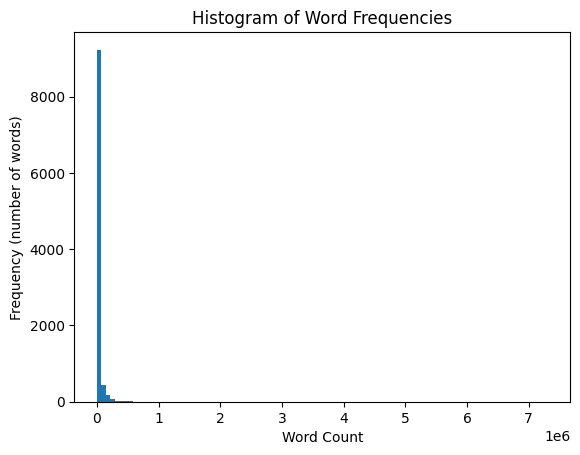

In [24]:
import matplotlib.pyplot as plt

df_preprocessed = pd.read_csv(preprocessed_reduced_vocab_stats_path)

plt.figure()
plt.hist(df_preprocessed["count"], bins=100)
plt.xlabel("Word Count")
plt.ylabel("Frequency (number of words)")
plt.title("Histogram of Word Frequencies")
plt.show()

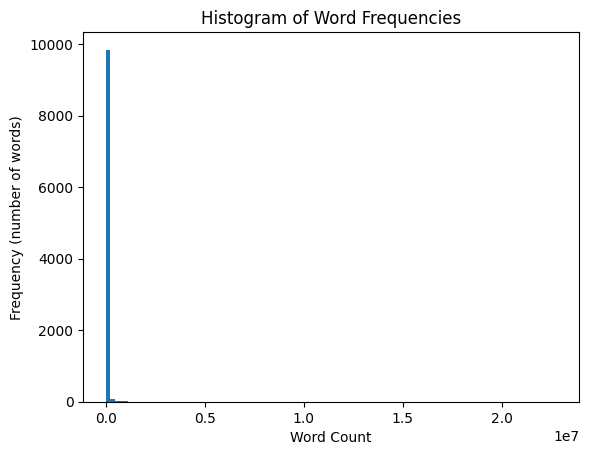

In [25]:
df_raw = pd.read_csv(raw_reduced_vocab_stats_path)

plt.figure()
plt.hist(df_raw["count"], bins=100)
plt.xlabel("Word Count")
plt.ylabel("Frequency (number of words)")
plt.title("Histogram of Word Frequencies")
plt.show()